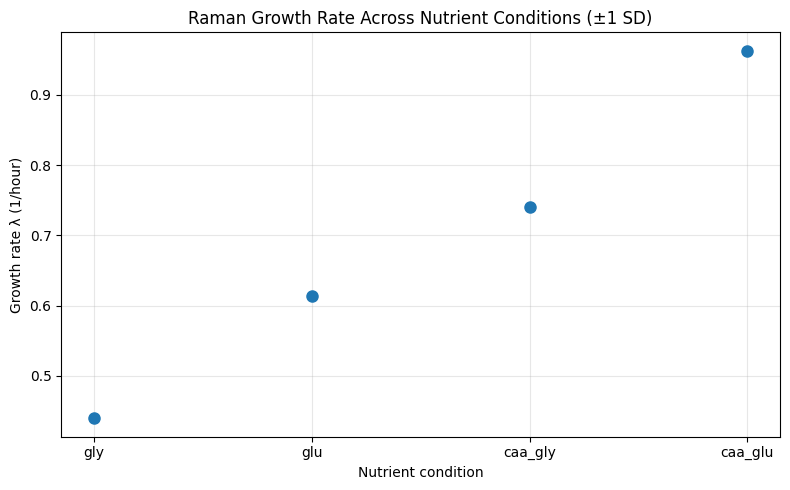

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load growth data
# ------------------------------------------------------------

growth_df = pd.read_csv("Data/RamanData/Raman_growth.csv")

# Filter no antibiotic
df0 = growth_df[growth_df["Dose"] == 0]

# ------------------------------------------------------------
# Compute mean and std per nutrient
# ------------------------------------------------------------

summary = (
    df0.groupby("Condition")["Value"]
    .agg(["mean", "std"])
    .reset_index()
)

# Sort by mean growth rate (optional, cleaner visual)
summary = summary.sort_values("mean")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.errorbar(
    summary["Condition"],
    summary["mean"],
    yerr=summary["std"],
    fmt='o',
    capsize=5,
    markersize=8
)

plt.xlabel("Nutrient condition")
plt.ylabel("Growth rate λ (1/hour)")
plt.title("Raman Growth Rate Across Nutrient Conditions (±1 SD)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In this notebook, the following linear regression analysis methods and measures will be used and calculated for the Raman data from the 2025 preprint Christoph Engl, Zechuan Gong and Andrey Sapelkin at Queen Mary University London: Spearman and Person correlation (rho), two-tailed p value, 95% confidence intervals, coefficient of determination (R^2). 

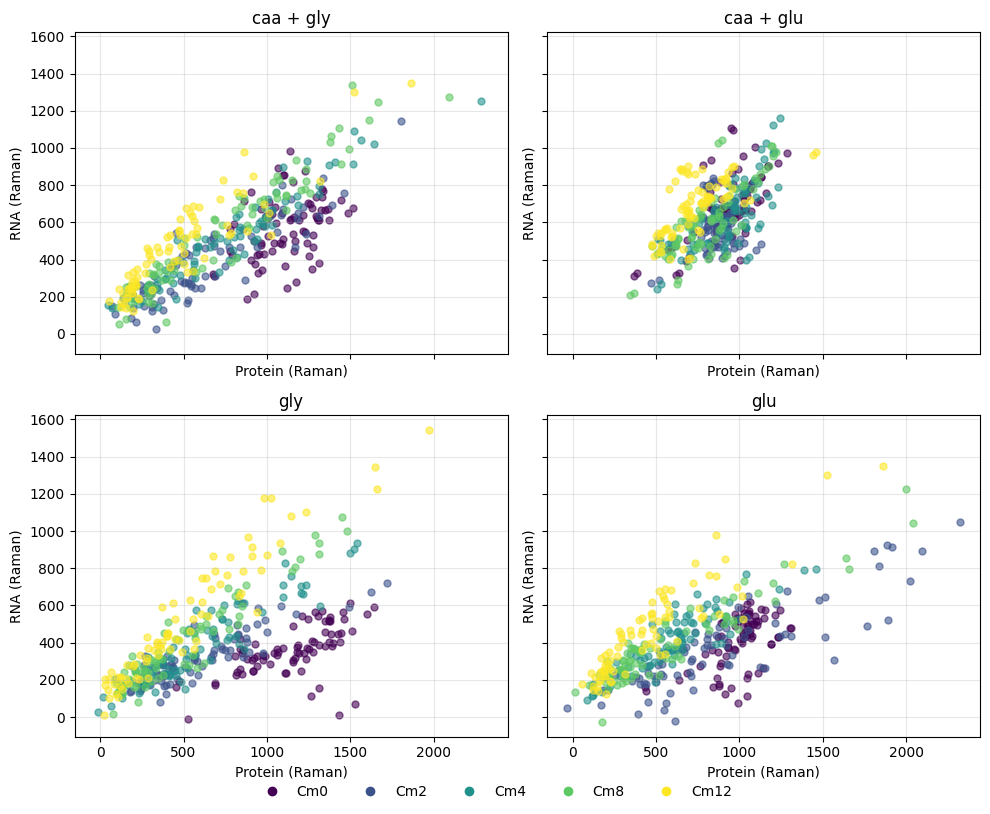

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load Raman RNA & Protein data
# ------------------------------------------------------------
rna_df     = pd.read_csv("Data/RamanData/rna.csv")
protein_df = pd.read_csv("Data/RamanData/protein.csv")
nutrients = ["caa_gly", "caa_glu", "gly", "glu"]
cm_levels = [0, 2, 4, 8, 12]
def colname(cm, nutrient):
    return f"Cm{cm}_{nutrient}"
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(cm_levels)))

for ax, nutrient in zip(axes, nutrients):

    for color, cm in zip(colors, cm_levels):

        col = colname(cm, nutrient)

        if col not in rna_df.columns or col not in protein_df.columns:
            continue

        RNA   = rna_df[col].dropna().values
        PROT  = protein_df[col].dropna().values

        # align lengths defensively
        N = min(len(RNA), len(PROT))
        RNA  = RNA[:N]
        PROT = PROT[:N]

        ax.scatter(
            PROT,
            RNA,
            s=25,
            alpha=0.6,
            color=color,
            label=f"Cm{cm}"
        )

    ax.set_title(nutrient.replace("_", " + "))
    ax.set_xlabel("Protein (Raman intensities)")
    ax.set_ylabel("RNA (Raman intensities)")
    ax.grid(alpha=0.3)

# ------------------------------------------------------------
# Shared legend
# ------------------------------------------------------------
handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        color=c,
        label=f"Cm{cm}"
    )
    for c, cm in zip(colors, cm_levels)
]

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout()
plt.show()


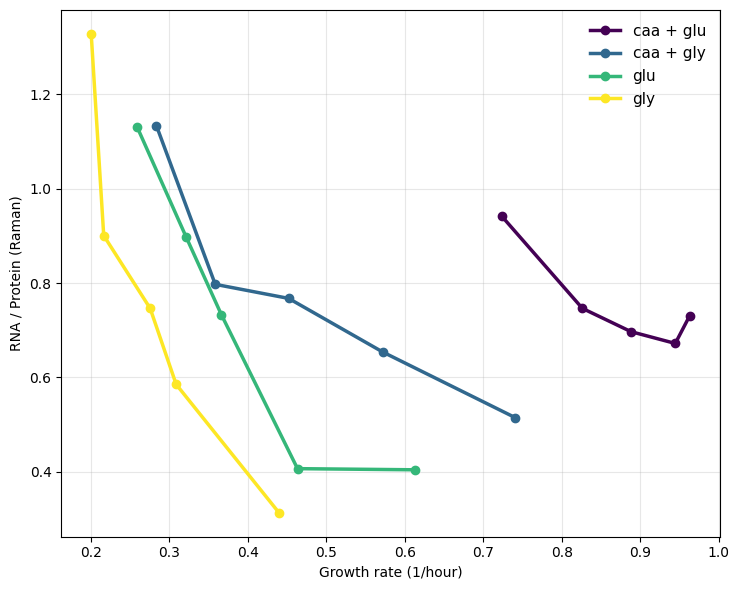

,Condition,Dose,growth,rna_protein
5,caa_glu,0,0.962800,0.730707
6,caa_glu,2,0.944421,0.671991
7,caa_glu,4,0.888092,0.696917
8,caa_glu,8,0.826125,0.746237
9,caa_glu,12,0.723262,0.941787
15,caa_gly,0,0.740254,0.515119
16,caa_gly,2,0.571827,0.653841
17,caa_gly,4,0.451967,0.767404
18,caa_gly,8,0.358470,0.797190
19,caa_gly,12,0.283624,1.132965


In [12]:
# ============================================================
# Raman RNA/Protein ratio vs Growth rate
# (wide RNA/Protein CSV, arrows = increasing Cm)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------
growth_df = pd.read_csv("Data/RamanData/Raman_growth.csv")
ratio_wide = pd.read_csv("Data/RamanData/rna_protein.csv")

# ------------------------------------------------------------
# Clean growth data
# ------------------------------------------------------------
growth_df = growth_df.rename(columns={"Value": "growth"})

# ------------------------------------------------------------
# Reshape RNA/Protein data (wide → long)
# ------------------------------------------------------------
records = []

for col in ratio_wide.columns:
    if not col.startswith("Cm"):
        continue

    # Parse column name: Cm{dose}_{condition}
    cm_part, condition = col.split("_", 1)
    dose = int(cm_part.replace("Cm", ""))

    values = ratio_wide[col].dropna().values

    for v in values:
        records.append({
            "Condition": condition,
            "Dose": dose,
            "rna_protein": v
        })

ratio_long = pd.DataFrame(records)

# ------------------------------------------------------------
# Average RNA/Protein per (Condition, Dose)
# ------------------------------------------------------------
ratio_mean = (
    ratio_long
    .groupby(["Condition", "Dose"], as_index=False)
    .mean()
)

# ------------------------------------------------------------
# Merge with growth data
# ------------------------------------------------------------
merged = pd.merge(
    growth_df,
    ratio_mean,
    on=["Condition", "Dose"],
    how="inner"
).sort_values(["Condition", "Dose"])

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(7.5, 6))

conditions = sorted(merged["Condition"].unique())
COLORS = plt.cm.viridis(np.linspace(0, 1, len(conditions)))

for color, cond in zip(COLORS, conditions):

    g = merged[merged["Condition"] == cond]

    x = g["growth"].values
    y = g["rna_protein"].values

    # Line + points
    plt.plot(
        x, y,
        "-o",
        lw=2.5,
        color=color,
        label=cond.replace("_", " + ")
    )
# ------------------------------------------------------------
# Directional annotation arrows (figure-style)
# ------------------------------------------------------------

# Chloramphenicol dose direction (top-left → bottom-right)
# plt.annotate(
#     "Chloramphenicol dose",
#     xy=(1, 0),        # arrow head (data coords)
#     xytext=(1, 1),    # arrow tail (data coords)
#     arrowprops=dict(
#         arrowstyle="->",
#         lw=2,
#         color="black"
#     ),
#     fontsize=14,
#     rotation=-28,
#     ha="center",
#     va="center"
# )

# # Nutrient strength direction (bottom-left → top-right)
# plt.annotate(
#     "Nutrient strength",
#     xy=(0.6, 1.2),        # arrow head
#     xytext=(1, 0.6),    # arrow tail
#     arrowprops=dict(
#         arrowstyle="->",
#         lw=2,
#         color="black"
#     ),
#     fontsize=14,
#     rotation=24,
#     ha="center",
#     va="center"
# )

plt.xlabel("Growth rate (1/hour)")
plt.ylabel("RNA / Protein (Raman)")
plt.grid(alpha=0.3)

plt.legend(
    frameon=False,
    fontsize=11
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Sanity check
# ------------------------------------------------------------
display(merged)


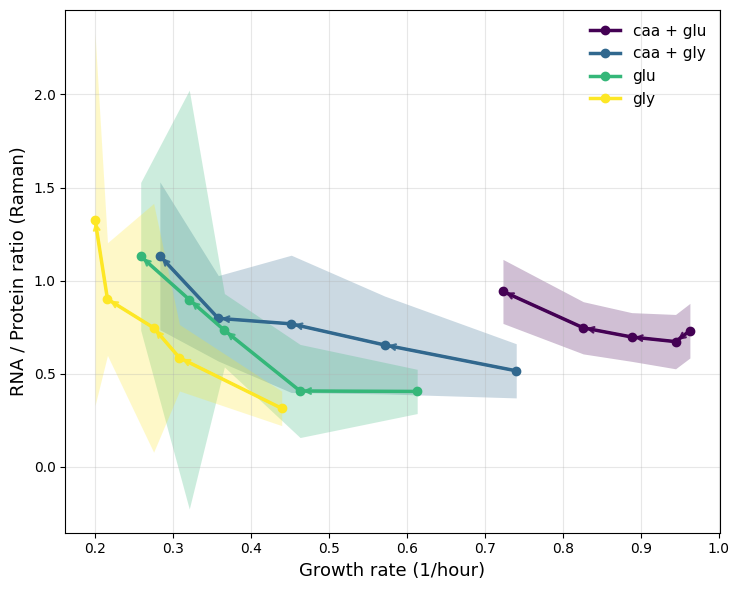

,Condition,Dose,growth,rp_mean,rp_std
0,caa_glu,0,0.962800,0.730707,0.146642
1,caa_glu,2,0.944421,0.671991,0.145976
2,caa_glu,4,0.888092,0.696917,0.130863
3,caa_glu,8,0.826125,0.746237,0.140319
4,caa_glu,12,0.723262,0.941787,0.171981
5,caa_gly,0,0.740254,0.515119,0.145471
6,caa_gly,2,0.571827,0.653841,0.262707
7,caa_gly,4,0.451967,0.767404,0.368854
8,caa_gly,8,0.358470,0.797190,0.229637
9,caa_gly,12,0.283624,1.132965,0.397030


In [13]:
# ============================================================
# Raman RNA / Protein ratio vs Growth rate
# Mean ± STD, arrows = increasing Cm
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load Raman data
# ------------------------------------------------------------
growth_df = pd.read_csv("Data/RamanData/Raman_growth.csv")
ratio_wide = pd.read_csv("Data/RamanData/rna_protein.csv")

# ------------------------------------------------------------
# Clean growth data
# ------------------------------------------------------------
growth_df = growth_df.rename(columns={"Value": "growth"})
growth_df = growth_df.sort_values(["Condition", "Dose"])

# ------------------------------------------------------------
# Reshape RNA/Protein data (wide → long)
# ------------------------------------------------------------
records = []

for col in ratio_wide.columns:
    if not col.startswith("Cm"):
        continue

    cm_part, condition = col.split("_", 1)
    dose = int(cm_part.replace("Cm", ""))

    for v in ratio_wide[col].dropna():
        records.append({
            "Condition": condition,
            "Dose": dose,
            "rna_protein": v
        })

ratio_long = pd.DataFrame(records)

# ------------------------------------------------------------
# Compute mean and STD per (Condition, Dose)
# ------------------------------------------------------------
rp_stats = (
    ratio_long
    .groupby(["Condition", "Dose"])
    .agg(
        rp_mean=("rna_protein", "mean"),
        rp_std=("rna_protein", "std")
    )
    .reset_index()
)

# ------------------------------------------------------------
# Merge with growth data
# ------------------------------------------------------------
merged = pd.merge(
    growth_df,
    rp_stats,
    on=["Condition", "Dose"],
    how="inner"
).sort_values(["Condition", "Dose"])

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(7.5, 6))

conditions = sorted(merged["Condition"].unique())
COLORS = plt.cm.viridis(np.linspace(0, 1, len(conditions)))

for color, cond in zip(COLORS, conditions):

    g = merged[merged["Condition"] == cond]

    x = g["growth"].values
    y = g["rp_mean"].values
    yerr = g["rp_std"].values

    # Mean curve
    plt.plot(
        x, y,
        "-o",
        lw=2.5,
        color=color,
        label=cond.replace("_", " + ")
    )

    # Shaded ±1 STD band
    plt.fill_between(
        x,
        y - yerr,
        y + yerr,
        color=color,
        alpha=0.25,
        linewidth=0
    )

    # Arrows indicating increasing Cm
    for i in range(len(x) - 1):
        plt.annotate(
            "",
            xy=(x[i+1], y[i+1]),
            xytext=(x[i], y[i]),
            arrowprops=dict(
                arrowstyle="->",
                lw=1.6,
                color=color,
                alpha=0.9
            )
        )

# ------------------------------------------------------------
# Axes & legend
# ------------------------------------------------------------
plt.xlabel("Growth rate (1/hour)", fontsize=13)
plt.ylabel("RNA / Protein ratio (Raman)", fontsize=13)
plt.grid(alpha=0.3)

plt.legend(
    frameon=False,
    fontsize=11
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Optional: inspect merged data
# ------------------------------------------------------------
display(merged)


/var/folders/2p/kflty7m55r712qwdgfdky9h80000gn/T/ipykernel_49587/2629963985.py:68: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  left["Condition"] = pd.Categorical(left["Condition"], nutrient_order)


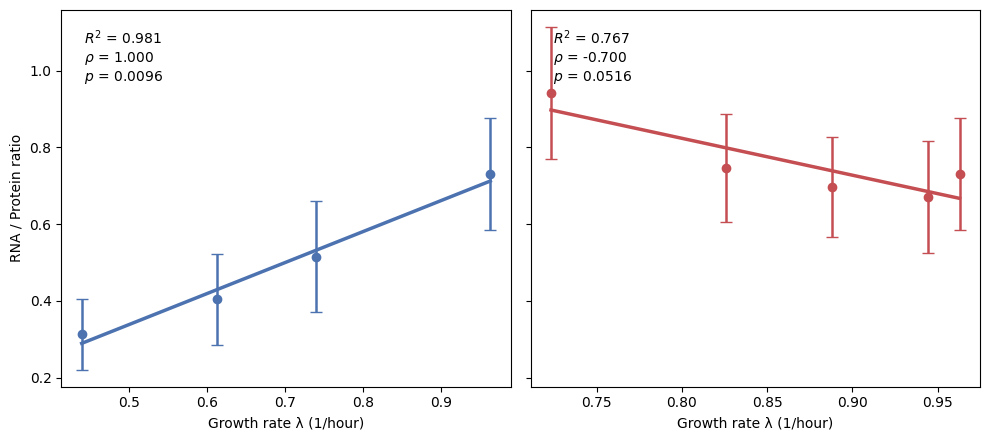

In [21]:
# ============================================================
# Raman RNA / Protein ratio vs Growth rate
# Scott-style replication
# - regression line (least squares)
# - statistics computed on points
# - pointwise ±STD error bars
# - NO arrows
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# ------------------------------------------------------------
# Load Raman data
# ------------------------------------------------------------
growth = pd.read_csv("Data/RamanData/Raman_growth.csv")
ratio_wide = pd.read_csv("Data/RamanData/rna_protein.csv")

growth = growth.rename(columns={"Value": "growth"})

# ------------------------------------------------------------
# Convert RNA/Protein wide → long
# ------------------------------------------------------------
records = []
for col in ratio_wide.columns:
    if not col.startswith("Cm"):
        continue
    cm, cond = col.split("_", 1)
    dose = int(cm.replace("Cm", ""))
    for v in ratio_wide[col].dropna():
        records.append({
            "Condition": cond,
            "Dose": dose,
            "rna_protein": v
        })

ratio = pd.DataFrame(records)

# ------------------------------------------------------------
# Aggregate mean ± STD
# ------------------------------------------------------------
rp_stats = (
    ratio
    .groupby(["Condition", "Dose"])
    .agg(
        rp_mean=("rna_protein", "mean"),
        rp_std=("rna_protein", "std")
    )
    .reset_index()
)

data = pd.merge(growth, rp_stats, on=["Condition", "Dose"])

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

# ============================================================
# LEFT PANEL — Nutrient quality (Cm = 0)
# ============================================================
ax = axes[0]

nutrient_order = ["gly", "glu", "caa_gly", "caa_glu"]
left = data[(data["Dose"] == 0) & (data["Condition"].isin(nutrient_order))]
left["Condition"] = pd.Categorical(left["Condition"], nutrient_order)
left = left.sort_values("Condition")

x = left["growth"].values
y = left["rp_mean"].values
yerr = left["rp_std"].values

# Regression line (for display)
coef = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 200)
ys = np.polyval(coef, xs)

# Statistics on points
R, pR = pearsonr(x, y)
rho, pS = spearmanr(x, y)

ax.plot(xs, ys, lw=2.5, color="#4c72b0")
ax.errorbar(
    x, y,
    yerr=yerr,
    fmt='o',
    color="#4c72b0",
    capsize=4,
    elinewidth=1.8
)

ax.text(
    0.05, 0.95,
    f"$R^2$ = {R**2:.3f}\n$\\rho$ = {rho:.3f}\n$p$ = {pR:.4f}",
    transform=ax.transAxes,
    va="top"
)

ax.set_xlabel("Growth rate λ (1/hour)")
ax.set_ylabel("RNA / Protein ratio")

# ============================================================
# RIGHT PANEL — Translation inhibition (fixed nutrient)
# ============================================================
ax = axes[1]

cond = "caa_glu"
right = data[data["Condition"] == cond].sort_values("Dose")

x = right["growth"].values
y = right["rp_mean"].values
yerr = right["rp_std"].values

coef = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 200)
ys = np.polyval(coef, xs)

R, pR = pearsonr(x, y)
rho, pS = spearmanr(x, y)

ax.plot(xs, ys, lw=2.5, color="#c44e52")
ax.errorbar(
    x, y,
    yerr=yerr,
    fmt='o',
    color="#c44e52",
    capsize=4,
    elinewidth=1.8
)

ax.text(
    0.05, 0.95,
    f"$R^2$ = {R**2:.3f}\n$\\rho$ = {rho:.3f}\n$p$ = {pR:.4f}",
    transform=ax.transAxes,
    va="top"
)

ax.set_xlabel("Growth rate λ (1/hour)")

# ------------------------------------------------------------
plt.tight_layout()
plt.show()
